## Chapter 7. 머신러닝 기초: 사이킷런과 선형 회귀

### 7.1

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

x = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])


#### 1)

In [12]:
w = 1.0

while w >= 0.3:
    y_pr = w * x
    mse = mean_squared_error(y, y_pr)
    
    print(f"w = {w:.1f}, 평균제곱 오차: {mse:.2f}")
    
    w -= 0.1

w = 1.0, 평균제곱 오차: 23.08
w = 0.9, 평균제곱 오차: 15.86
w = 0.8, 평균제곱 오차: 10.13
w = 0.7, 평균제곱 오차: 5.89
w = 0.6, 평균제곱 오차: 3.13
w = 0.5, 평균제곱 오차: 1.85
w = 0.4, 평균제곱 오차: 2.06
w = 0.3, 평균제곱 오차: 3.75


#### 2)

In [26]:
l = np.arange(1.0, 0.2, -0.1)

y_pr = l[:, None] * x

m = np.mean((y - y_pr) ** 2, axis=1)

print(f"평균제곱 오차가 가장 클 때 w값: {l[np.argmax(m)]:.1f}\n평균제곱 오차가 가장 작을 때 w값: {l[np.argmin(m)]:.1f}")

평균제곱 오차가 가장 클 때 w값: 1.0
평균제곱 오차가 가장 작을 때 w값: 0.5


In [ ]:
w = 1.0
l = []
m = []

while w >= 0.3:
    y_pr = w * x
    mse = mean_squared_error(y, y_pr)
    l.append(mse)
    m.append(w)
    
    w -= 0.1

print(f"평균제곱 오차가 가장 클 때 w값: {m[l.index(max(l))]:.1f}\n평균제곱 오차가 가장 작을 때 w값: {m[l.index(min(l))]:.1f}")

평균제곱 오차가 가장 클 때 w값: 1.0
평균제곱 오차가 가장 작을 때 w값: 0.5


#### 3)

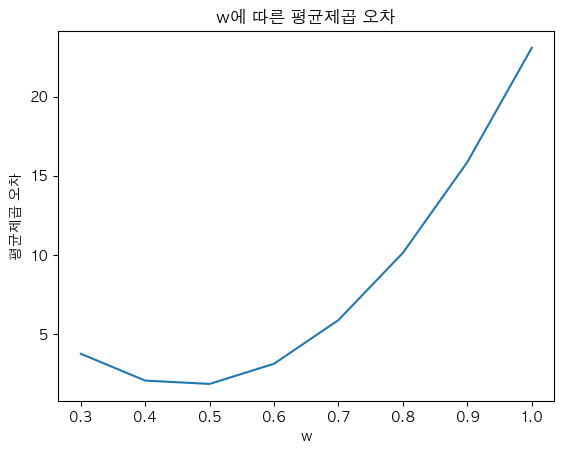

In [29]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'

l = np.arange(1.0, 0.2, -0.1)

y_pr = l[:, None] * x
m = np.mean((y - y_pr) ** 2, axis=1)

plt.plot(l, m)
plt.xlabel("w")
plt.ylabel("평균제곱 오차")
plt.title("w에 따른 평균제곱 오차")

plt.show()

### 7.2

In [36]:
import seaborn as sns

flights = sns.load_dataset('flights')

print(f"flights 데이터의 shape: {flights.shape}\n\n{flights.head()}")

flights 데이터의 shape: (144, 3)

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


#### 1)

In [45]:
print(flights.groupby('year', observed=True)['passengers'].sum())

year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: passengers, dtype: int64


#### 2)

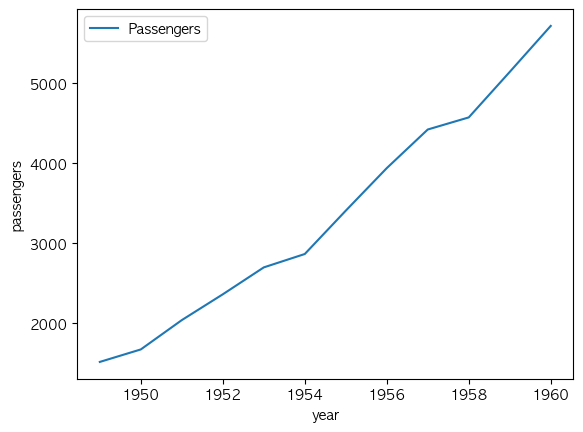

In [54]:
import matplotlib.pyplot as plt

f = flights.groupby('year', observed=True)['passengers'].sum()

plt.plot(f.index, f.values, label='Passengers')
plt.xlabel("year")
plt.ylabel("passengers")

plt.legend()
plt.show()

#### 3)

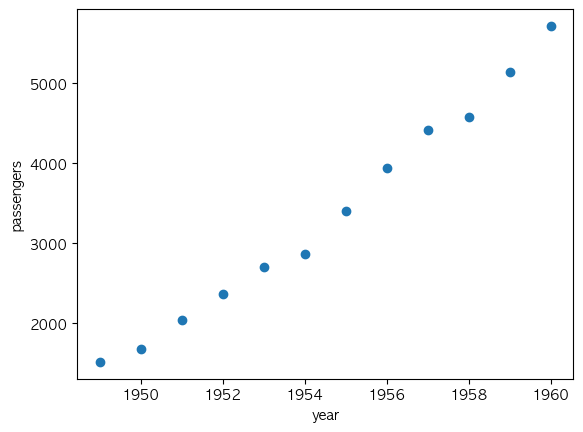

In [57]:
f = flights.groupby('year', observed=True)['passengers'].sum()

plt.scatter(f.index, f.values)  
plt.xlabel("year")
plt.ylabel("passengers")

plt.show()

#### 4)

In [82]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

f = flights.groupby('year', observed=True)['passengers'].sum()

x = f.index.values.reshape(-1, 1)
y = f.values

model = LinearRegression()
model.fit(x, y)

score = model.score(x, y)
print(f"선형 회귀 모델의 계수: {model.coef_}\n선형 회귀 모델의 절편: {model.intercept_:.2f}\n데이터와 선형 회귀 직선의 관계점수: {score*100:.1f}%")

선형 회귀 모델의 계수: [383.08741259]
선형 회귀 모델의 절편: -745380.76
데이터와 선형 회귀 직선의 관계점수: 98.7%


#### 5)

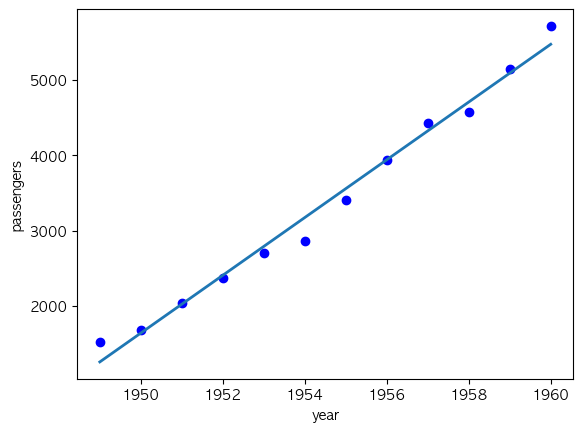

In [64]:
plt.scatter(x, y, color='blue', label='실제 승객 수')
plt.plot(x, model.predict(x), linewidth=2)

plt.xlabel("year")
plt.ylabel("passengers")

plt.show()

### 7.3

In [74]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

y = np.array([1.2, 2.4, 2.5, 4.6, 5.4])
y_hat = np.array([1, 2, 3, 4, 5])

m = mean_squared_error(y, y_hat)
r = r2_score(y, y_hat)

mm = mean_squared_error(y * 10, y_hat * 10)
rr = r2_score(y * 10, y_hat * 10)

print(f"평균 제곱 오차\n{m:.1f} → {mm}\n\nR^2\n{r} → {rr}")

평균 제곱 오차
0.2 → 19.4

R^2
0.9186787391012743 → 0.9186787391012743


### 7.4

In [77]:
import pandas as pd

path = 'http://github.com/dongupak/DataML/raw/main/csv/'
file = path+'data_house.csv'
df = pd.read_csv(file)

#### 1)

In [79]:
print(f"df.describe() 결과\n{df.describe()}")

df.describe() 결과
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio       lstat  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534   12.653063   
std     28

In [80]:
print(f"df.info() 결과\n{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB
df.info() 결과
None


#### 2)

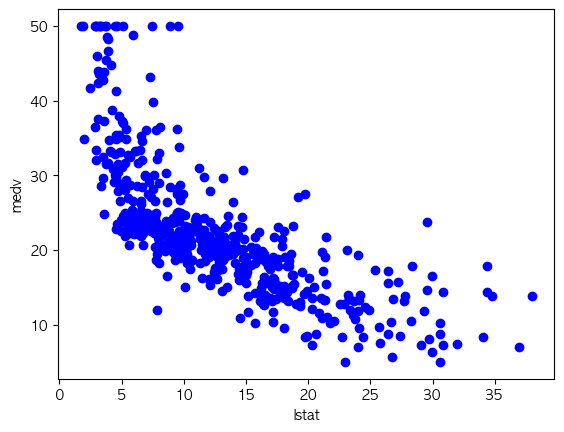

In [81]:
import matplotlib.pyplot as plt

x = df['lstat']
y = df['medv']

plt.plot(x, y, 'o', color='blue') 
plt.xlabel('lstat')
plt.ylabel('medv')

plt.show()

#### 3)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df[['lstat']]  
y = df['medv']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3) 

model = LinearRegression()
model.fit(x_train, y_train)

score = model.score(x_test, y_test)
print(f"선형 회귀 모델의 계수: {model.coef_}\n선형 회귀 모델의 절편: {model.intercept_}\n데이터와 선형 회귀 직선의 관계점수: {score*100:.2f}%")

선형 회귀 모델의 계수: [-0.94577859]
선형 회귀 모델의 절편: 34.412708519627365
데이터와 선형 회귀 직선의 관계점수: 55.34%


#### 4)

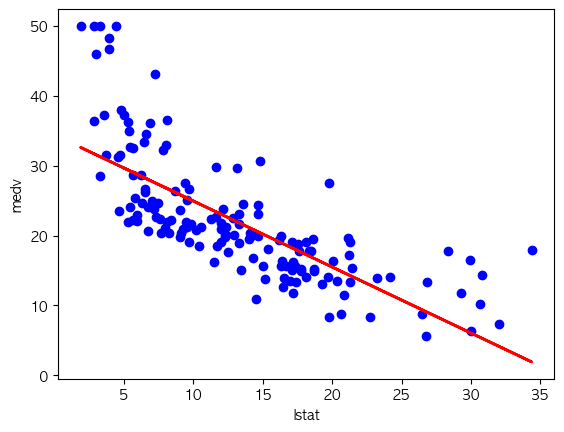

In [85]:
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test, y_pred, color='red', linewidth=2)

plt.xlabel('lstat')
plt.ylabel('medv')

plt.show()